In [1]:
# --------------------------
# Import bibliotek
# --------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
# --------------------------
# Wczytanie danych
# --------------------------
df = pd.read_csv("weather.csv")
print("Rozmiar danych:", df.shape)
df.head()

Rozmiar danych: (366, 24)


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2007-11-01,Canberra,8.0,24.3,0.0,3.4,6.3,NW,30.0,SW,...,29,1019.7,1015.0,7,7,14.4,23.6,No,3.6,Yes
1,2007-11-02,Canberra,14.0,26.9,3.6,4.4,9.7,ENE,39.0,E,...,36,1012.4,1008.4,5,3,17.5,25.7,Yes,3.6,Yes
2,2007-11-03,Canberra,13.7,23.4,3.6,5.8,3.3,NW,85.0,N,...,69,1009.5,1007.2,8,7,15.4,20.2,Yes,39.8,Yes
3,2007-11-04,Canberra,13.3,15.5,39.8,7.2,9.1,NW,54.0,WNW,...,56,1005.5,1007.0,2,7,13.5,14.1,Yes,2.8,Yes
4,2007-11-05,Canberra,7.6,16.1,2.8,5.6,10.6,SSE,50.0,SSE,...,49,1018.3,1018.5,7,7,11.1,15.4,Yes,0.0,No


In [3]:
# --------------------------
# Podstawowa eksploracja danych
# --------------------------
print(df.info())
print(df.describe())
print(df.isnull().sum().sort_values(ascending=False))
print(df['RainTomorrow'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           366 non-null    object 
 1   Location       366 non-null    object 
 2   MinTemp        366 non-null    float64
 3   MaxTemp        366 non-null    float64
 4   Rainfall       366 non-null    float64
 5   Evaporation    366 non-null    float64
 6   Sunshine       363 non-null    float64
 7   WindGustDir    363 non-null    object 
 8   WindGustSpeed  364 non-null    float64
 9   WindDir9am     335 non-null    object 
 10  WindDir3pm     365 non-null    object 
 11  WindSpeed9am   359 non-null    float64
 12  WindSpeed3pm   366 non-null    int64  
 13  Humidity9am    366 non-null    int64  
 14  Humidity3pm    366 non-null    int64  
 15  Pressure9am    366 non-null    float64
 16  Pressure3pm    366 non-null    float64
 17  Cloud9am       366 non-null    int64  
 18  Cloud3pm  

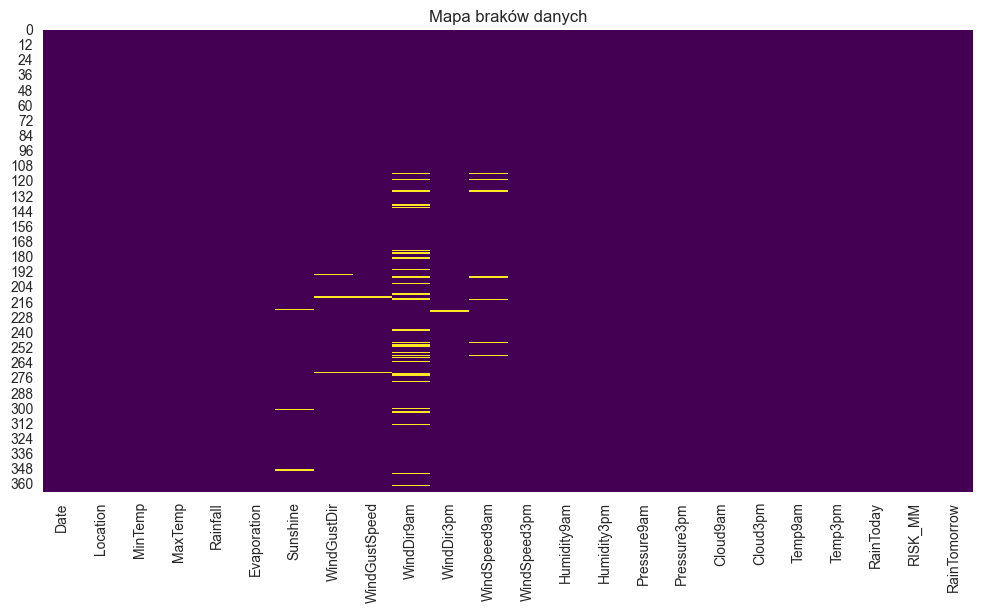

In [4]:
# --------------------------
# Wizualizacja braków danych
# --------------------------
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Mapa braków danych")
plt.show()

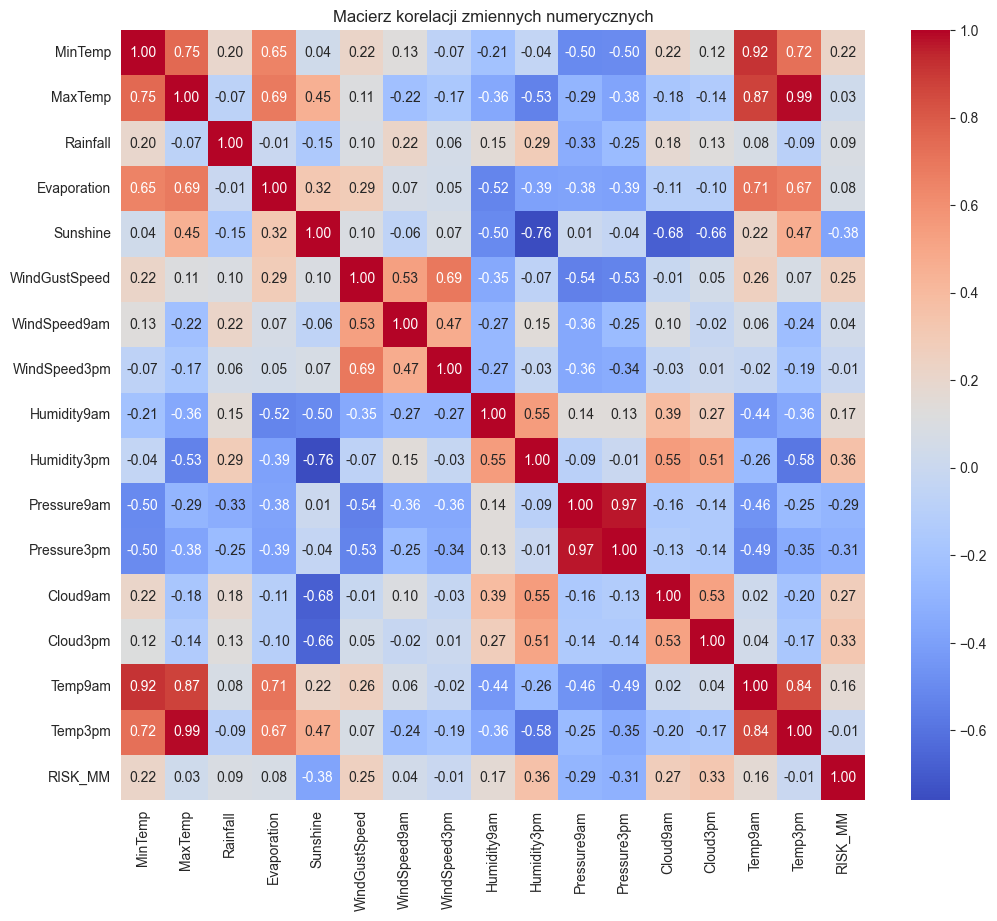

In [5]:
# --------------------------
# Analiza korelacji zmiennych numerycznych
# --------------------------
num_cols = df.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(12, 10))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Macierz korelacji zmiennych numerycznych")
plt.show()

In [6]:
# --------------------------
# Usunięcie nieistotnych kolumn
# --------------------------
df = df.drop(columns=["Date", "Location", "RainToday", "RISK_MM"])

In [7]:
# --------------------------
# Konwersja zmiennej celu
# --------------------------
df["RainTomorrow"] = df["RainTomorrow"].map({"No": 0, "Yes": 1})

In [8]:
# --------------------------
# Identyfikacja kolumn numerycznych i kategorycznych
# --------------------------
num_cols = df.select_dtypes(include=np.number).columns.drop("RainTomorrow")
cat_cols = df.select_dtypes(include="object").columns
print("Cechy numeryczne:", num_cols)
print("Cechy kategoryczne:", cat_cols)

Cechy numeryczne: Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm'],
      dtype='object')
Cechy kategoryczne: Index(['WindGustDir', 'WindDir9am', 'WindDir3pm'], dtype='object')


In [9]:
# --------------------------
# Podział danych na X i y
# --------------------------
X = df.drop("RainTomorrow", axis=1)
y = df["RainTomorrow"]

In [10]:
# --------------------------
# Podział na zbiór treningowy i testowy
# --------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
# --------------------------
# Pipeline dla cech numerycznych i kategorycznych
# --------------------------
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

In [12]:
# --------------------------
# Definicja modeli
# --------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}


Logistic Regression - Test set
----------------------------------------
              precision    recall  f1-score   support

           0       0.93      0.87      0.90        61
           1       0.53      0.69      0.60        13

    accuracy                           0.84        74
   macro avg       0.73      0.78      0.75        74
weighted avg       0.86      0.84      0.85        74



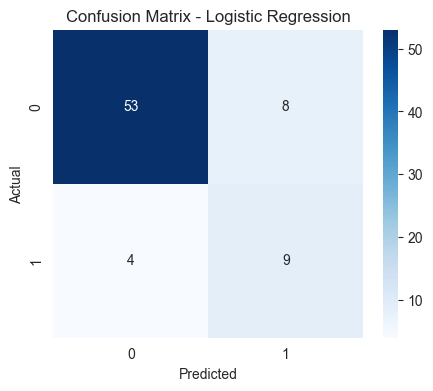

Logistic Regression - Cross-validated F1-score: 0.604 ± 0.116

Decision Tree - Test set
----------------------------------------
              precision    recall  f1-score   support

           0       0.90      0.77      0.83        61
           1       0.36      0.62      0.46        13

    accuracy                           0.74        74
   macro avg       0.63      0.69      0.64        74
weighted avg       0.81      0.74      0.77        74



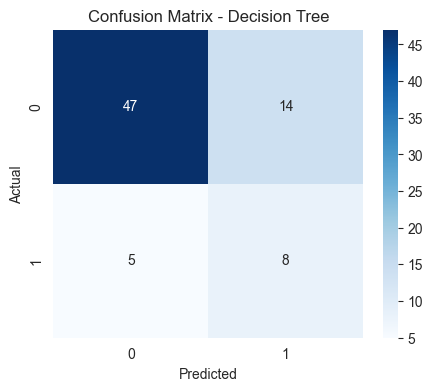

Decision Tree - Cross-validated F1-score: 0.383 ± 0.124

Random Forest - Test set
----------------------------------------
              precision    recall  f1-score   support

           0       0.90      1.00      0.95        61
           1       1.00      0.46      0.63        13

    accuracy                           0.91        74
   macro avg       0.95      0.73      0.79        74
weighted avg       0.92      0.91      0.89        74



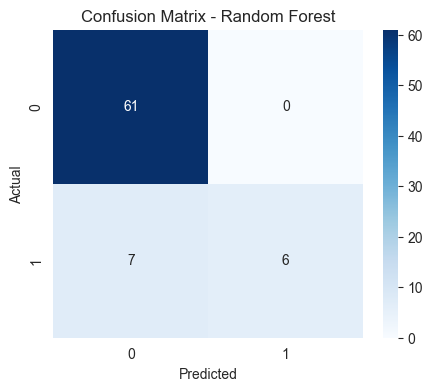

Random Forest - Cross-validated F1-score: 0.405 ± 0.050


In [13]:
# --------------------------
# Trenowanie modeli, predykcje i cross-validation
# --------------------------
results = []
results_cv = []

for name, clf in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", clf)
    ])

    # Fit na zbiorze treningowym
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    # Ewaluacja na zbiorze testowym
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, acc, prec, rec, f1])

    print(f"\n{name} - Test set")
    print("-" * 40)
    print(classification_report(y_test, y_pred))

    # Macierz konfuzji
    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Cross-validation (F1-score)
    cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='f1')
    mean_cv = cv_scores.mean()
    std_cv = cv_scores.std()
    results_cv.append([name, mean_cv, std_cv])
    print(f"{name} - Cross-validated F1-score: {mean_cv:.3f} ± {std_cv:.3f}")

In [14]:
# --------------------------
# Porównanie modeli w tabelach
# --------------------------
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"])
results_df = results_df.sort_values(by="F1-score", ascending=False)
print("\nPorównanie modeli - Test set:")
print(results_df)

results_cv_df = pd.DataFrame(results_cv, columns=["Model", "F1-score (mean)", "F1-score (std)"])
print("\nPorównanie modeli - Walidacja krzyżowa:")
print(results_cv_df)


Porównanie modeli - Test set:
                 Model  Accuracy  Precision    Recall  F1-score
2        Random Forest  0.905405   1.000000  0.461538  0.631579
0  Logistic Regression  0.837838   0.529412  0.692308  0.600000
1        Decision Tree  0.743243   0.363636  0.615385  0.457143

Porównanie modeli - Walidacja krzyżowa:
                 Model  F1-score (mean)  F1-score (std)
0  Logistic Regression         0.604212        0.116206
1        Decision Tree         0.382670        0.124435
2        Random Forest         0.405486        0.050224
